# E-Commerce Funnel & Conversion Analysis

## Introduction

Understanding how users interact with an e-commerce platform is essential for improving customer experience and increasing revenue. Every customer typically goes through a journey before making a purchase. This journey often follows a funnel structure:

**Product View → Add to Cart → Purchase**

At each stage of this funnel, some users drop off before completing the purchase. Identifying where these drop-offs occur helps businesses optimize their marketing strategies, product pages, and checkout processes.

In this project, we analyze a large-scale e-commerce behavioral dataset containing millions of user interaction events. Each event represents an action performed by a user, such as viewing a product, adding it to a cart, or completing a purchase.

The goal of this analysis is to understand user behavior patterns, identify conversion bottlenecks in the purchasing funnel, and generate actionable insights that can help improve conversion rates and overall revenue.

The analysis includes multiple stages of data analytics and machine learning, including data cleaning, exploratory data analysis, funnel analysis, customer segmentation, cohort analysis, user journey analysis, and purchase prediction modeling.

By combining behavioral analytics with machine learning techniques, this project demonstrates how data can be used to understand customer behavior and support data-driven decision-making in e-commerce businesses.

---

## Objectives of the Project

The main objectives of this project are:

• Analyze user interaction data to understand customer behavior  
• Identify drop-off points in the e-commerce conversion funnel  
• Measure key performance metrics such as conversion rates and cart abandonment  
• Explore purchasing patterns across categories, time periods, and users  
• Segment customers based on their purchasing behavior  
• Perform cohort analysis to study customer retention patterns  
• Predict purchase likelihood using machine learning models  
• Generate business recommendations to improve conversion and revenue

---

## Project Workflow

The project follows a structured data analytics pipeline:

1. Data Understanding and Exploration  
2. Data Cleaning and Feature Engineering  
3. Exploratory Data Analysis (EDA)  
4. Funnel and Conversion Analysis  
5. Customer Behavior Analysis  
6. Advanced Analytics (Cohort and Journey Analysis)  
7. Machine Learning for Purchase Prediction  
8. Business Insights and Recommendations

This end-to-end approach simulates a real-world data analytics project commonly performed by product analysts and growth analysts in e-commerce companies.

**2) Dataset Overview**

## Dataset Description

This project uses the **E-Commerce Behavior Data from Multi-Category Store** dataset, which contains real-world anonymized user interaction data from an online retail platform. The dataset records millions of user activity events collected over a period of time and provides insights into how customers interact with products before making purchasing decisions.

Each row in the dataset represents a single user interaction event. These events capture different types of user actions such as viewing a product, adding a product to the shopping cart, or completing a purchase.

This dataset is particularly useful for analyzing customer behavior patterns, understanding conversion funnels, and identifying opportunities to improve user engagement and revenue generation.

---

## Dataset Source

Dataset: E-Commerce Behavior Data from Multi-Category Store  
Source: Kaggle  
Purpose: User behavior analysis and conversion funnel analysis in an e-commerce environment.

The dataset contains millions of records and multiple variables describing user actions, product information, and session details.

---

## Key Columns in the Dataset

The dataset includes the following important columns:

**event_time**  
Timestamp representing the exact time when the user interaction occurred.

**event_type**  
Type of user interaction event. Possible values include:
- view (user viewed a product)
- cart (user added a product to the cart)
- purchase (user completed the purchase)

**product_id**  
Unique identifier assigned to each product in the store.

**category_id**  
Unique identifier representing the product category.

**category_code**  
Text-based category label providing hierarchical category information (e.g., electronics.smartphone).

**brand**  
Brand name associated with the product.

**price**  
Price of the product at the time of the interaction.

**user_id**  
Unique identifier assigned to each user in the dataset.

**user_session**  
Identifier representing a browsing session. A session groups multiple user interactions occurring within the same browsing period.

---

## Dataset Characteristics

The dataset has the following characteristics:

• Large-scale behavioral dataset with millions of interaction records  
• Multiple event types representing different stages of the purchasing funnel  
• Session-level and user-level interaction tracking  
• Product and category metadata for business analysis

This dataset enables detailed analysis of the **customer journey**, allowing us to understand how users progress through the purchasing funnel and where they drop off before completing transactions.

---

## Relevance to Business Analytics

Analyzing user interaction data is crucial for e-commerce businesses because it helps answer important questions such as:

• How many users convert from viewing products to making purchases?  
• At which stage do most users abandon the purchasing process?  
• Which products or categories generate the highest engagement and revenue?  
• What behavioral patterns lead to successful purchases?

By analyzing these patterns, businesses can optimize product pages, improve checkout processes, and design more effective marketing strategies to increase conversions and revenue.

# Import Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Optional advanced visualization
import plotly.express as px
import plotly.graph_objects as go

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "2019-Oct.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mkechinov/ecommerce-behavior-data-from-multi-category-store",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
First 5 records:                 event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

 

### Dataset Preview

The first five rows of the dataset provide an overview of the data structure. Each row represents a specific user interaction with a product on the platform.

From the preview, we can observe important information such as:
- The timestamp of the event (`event_time`)
- The type of user action (`event_type`)
- Product identifiers
- Product categories
- Brand information
- Product price
- User identifiers
- Session identifiers

For example, the dataset shows that a user viewed a smartphone product from the Apple brand priced at 1081.98.

In [3]:
df.shape

(42448764, 9)

### Dataset Size

The dataset contains **42,448,764 rows** and **9 columns**.

Each row represents a single user interaction event. These events capture different user activities such as viewing products, adding items to the cart, and completing purchases.

The large number of records indicates that the dataset captures extensive user activity on the e-commerce platform, making it suitable for analyzing customer behavior and marketing funnel performance.

In [4]:
df.info() # contains both numerical and categorical variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


### Column Information

The dataset consists of 9 columns with different data types.

- **Object columns** represent categorical or textual information such as event type, product category, brand, and session identifiers.
- **Integer columns** represent numerical identifiers such as product IDs and user IDs.
- **Float columns** represent numerical values such as product prices.

The dataset uses a combination of categorical and numerical variables to describe user interactions and product attributes.







### Column Descriptions

event_time  
Timestamp indicating when the user interaction occurred.

event_type  
Type of user action performed on the platform. Common values include:
- view
- cart
- purchase

product_id  
Unique identifier assigned to each product.

category_id  
Unique identifier for the product category.

category_code  
Textual representation of the product category.

brand  
Brand name associated with the product.

price  
Price of the product in the store.

user_id  
Unique identifier assigned to each user.

user_session  
Unique identifier representing a user's browsing session.

### Key Observations

Several important observations can be made from the dataset overview:

- The dataset contains over **42 million user interaction records**, indicating large-scale user activity.
- The dataset includes multiple types of user actions such as product views, cart additions, and purchases.
- Product information such as category, brand, and price is available, enabling product-level analysis.
- The presence of session data allows analysis of user browsing behavior.
- Some categorical fields such as category_code and brand contain missing values, which will be handled during the data cleaning stage.

### 2.6 Event Type Distribution

The `event_type` column represents the type of interaction a user performs on the e-commerce platform.

Common user actions include:
- **view** – when a user views a product page
- **cart** – when a user adds a product to the cart
- **purchase** – when a user completes a purchase

Understanding the distribution of these actions helps identify user engagement patterns and forms the foundation for funnel analysis.

In [5]:
event_counts = df["event_type"].value_counts()

event_counts

,count
event_type,
view,40779399
cart,926516
purchase,742849


In [6]:
# coverting the DataFrame cleaner
event_counts_df = event_counts.reset_index()
event_counts_df.columns = ["event_type", "count"]

event_counts_df

,event_type,count
0,view,40779399
1,cart,926516
2,purchase,742849


In [7]:
# calculating percentages
event_counts_df["percentage"] = (
    event_counts_df["count"] / event_counts_df["count"].sum() * 100
)

event_counts_df

,event_type,count,percentage
0,view,40779399,96.067341
1,cart,926516,2.182669
2,purchase,742849,1.749990


# visualizing the Distribution

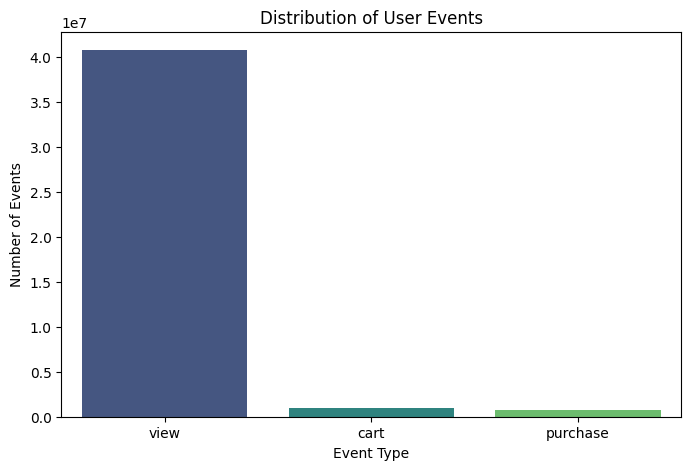

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=event_counts_df,
    x="event_type",
    y="count",
    palette="viridis"
)

plt.title("Distribution of User Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

plt.show()

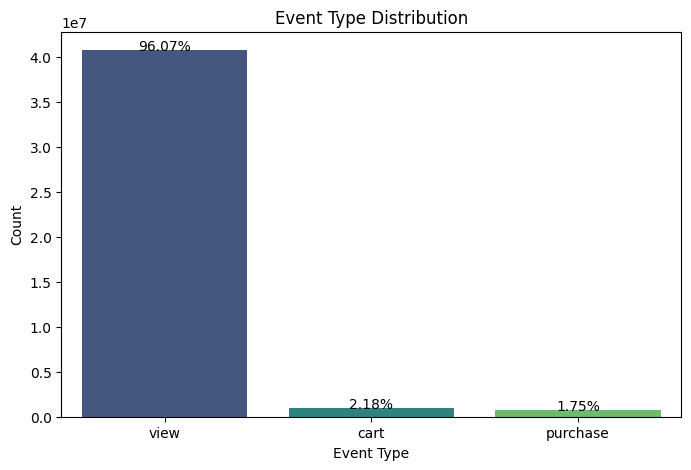

In [9]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=event_counts_df,
    x="event_type",
    y="count",
    palette="viridis"
)

for i,row in event_counts_df.iterrows():
    ax.text(i,row["count"],f'{row["percentage"]:.2f}%',ha='center')

plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

### Observations

From the event type distribution, we can observe that:

- The majority of interactions are **product views**, indicating that many users browse products on the platform.
- A smaller portion of users add products to their carts.
- An even smaller percentage of users complete purchases.

This pattern reflects a typical e-commerce funnel where many users enter the funnel through product views, but only a fraction progress to the final purchase stage.

These insights will be further explored in the funnel analysis section.

### 2.7 Missing Values Analysis


The presence of missing values in a dataset can affect the accuracy of analysis and machine learning models.

In this step, we examine the dataset to identify missing values across different columns. Understanding where missing values occur helps determine the appropriate data cleaning strategy.

Some columns such as product categories or brand names may naturally contain missing information, which needs to be handled carefully.

In [10]:
missing_values = df.isnull().sum()

missing_values

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,13515609
brand,6117080
price,0
user_id,0
user_session,2


In [11]:
# coverting the table into cleaner
missing_df = missing_values.reset_index()

missing_df.columns = ["column", "missing_count"]

missing_df

,column,missing_count
0,event_time,0
1,event_type,0
2,product_id,0
3,category_id,0
4,category_code,13515609
5,brand,6117080
6,price,0
7,user_id,0
8,user_session,2


In [12]:
# calculating missing per...
missing_df["missing_percentage"] = (
    missing_df["missing_count"] / len(df) * 100
)

missing_df

,column,missing_count,missing_percentage
0,event_time,0,0.000000
1,event_type,0,0.000000
2,product_id,0,0.000000
3,category_id,0,0.000000
4,category_code,13515609,31.839818
5,brand,6117080,14.410502
6,price,0,0.000000
7,user_id,0,0.000000
8,user_session,2,0.000005


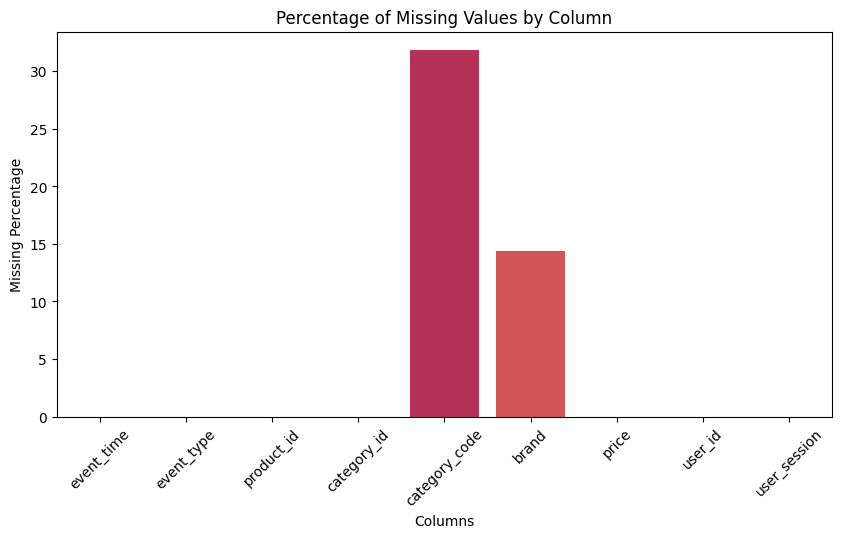

In [13]:
# visualizing the misssing values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=missing_df,
    x="column",
    y="missing_percentage",
    palette="rocket"
)
plt.xticks(rotation=45)
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")
plt.show()

### Observations

From the missing values analysis, we observe that:

- The `category_code` column contains a significant number of missing values.
- The `brand` column also contains missing entries.
- Columns such as `price`, `user_id`, and `product_id` do not contain missing values.

Missing values in `category_code` and `brand` are common in e-commerce datasets because not all products have defined categories or brand information.

These missing values will be handled in the data cleaning stage to ensure accurate analysis.

# 3) Data Clenaing

3.1) Data cleaning is the process of preparing raw data for analysis by fixing inconsistencies, missing values, duplicates, and data types.

In this dataset, we will:
- Convert timestamps to datetime format
- Handle missing values
- Remove duplicate records
- Standardize categories and text
- Ensure numeric values are correct

Clean data ensures accurate analysis in the later steps such as funnel analysis and revenue insights.

In [14]:
# 3.2 converting event tym to date tym

# Convert to datetime
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

# Verify
df["event_time"].dtype     #event_time is datetime64[ns, UTC], which makes it easier for time-based analysis..

datetime64[ns, UTC]

In [15]:
# handling the missing values
# we see thw missing values in the bramnd and the category_code
df["brand"].fillna("unknown", inplace=True)
df["category_code"].fillna("unknown", inplace=True)

In [16]:
# checking again
df[["brand","category_code"]].isnull().sum()

,0
brand,0
category_code,0


In [17]:
# checking the price coloumn
# Find invalid prices
df[df["price"] <= 0].shape

(68673, 9)

In [18]:
# Remove rows with price <= 0
df = df[df["price"] > 0]

In [19]:
# Extract main category (first part before dot)
df["main_category"] = df["category_code"].apply(lambda x: str(x).split(".")[0] if x != "unknown" else "unknown")

df["main_category"].value_counts().head(10)  # helps later for category-based funnel analysis.

,count
main_category,
electronics,16124907
unknown,13478561
appliances,4963333
computers,2321338
apparel,1537393
furniture,1242152
auto,1012448
construction,730055
kids,519821


In [20]:
# cheeck the user sessions
df["user_session"].nunique()
df["user_id"].nunique()

3021435

In [21]:
df_sample = df.sample(1000000, random_state=42)  # 1 million rows

In [22]:
# checking and removing the duplicates
duplicate_count = df.duplicated(subset=["user_session","event_time","product_id","event_type"]).sum()
print("Number of duplicates:", duplicate_count)

Number of duplicates: 30218


In [23]:
df.drop_duplicates(subset=["user_session","event_time","product_id","event_type"], inplace=True)

In [24]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 42349873 entries, 0 to 42448763
Data columns (total 10 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
 9   main_category  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(5)
memory usage: 3.5+ GB


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,2
main_category,0


In [25]:
# Fill the remaining missing user_session values
df["user_session"].fillna("unknown", inplace=True)

# Verify
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,0
main_category,0


## EDA

event_type
view        40708806
cart          898294
purchase      742773
Name: count, dtype: int64


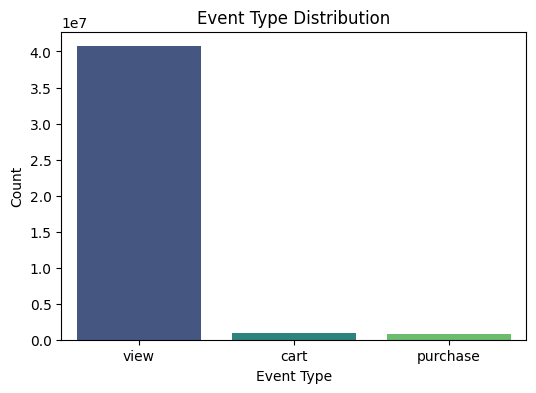

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each event type
event_counts = df['event_type'].value_counts()
print(event_counts)

# Visualize
plt.figure(figsize=(6,4))
sns.barplot(x=event_counts.index, y=event_counts.values, palette="viridis")
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

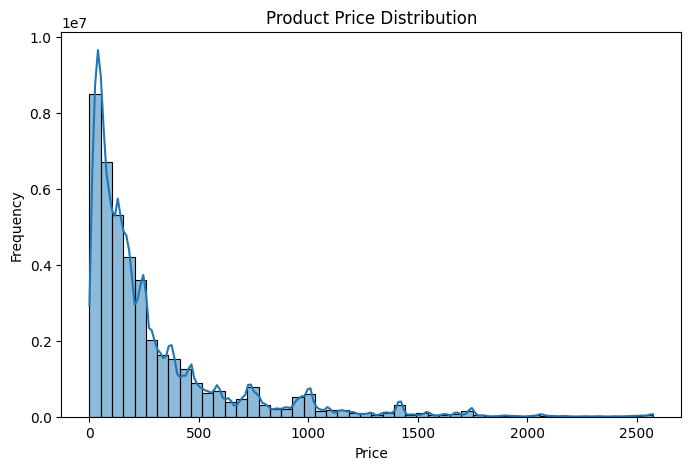

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

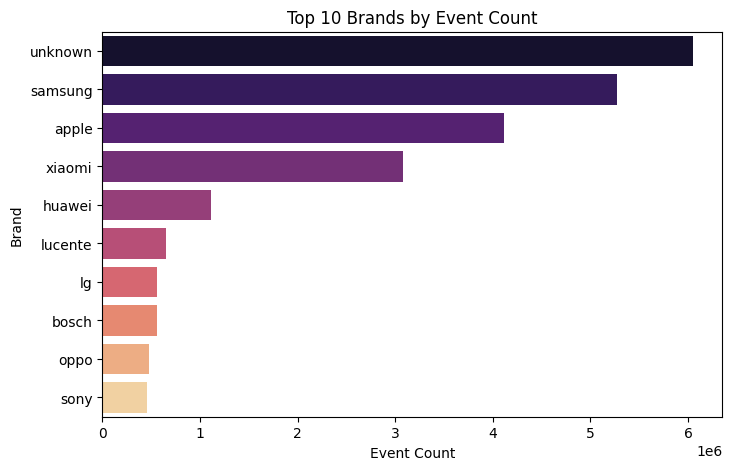

In [28]:
top_brands = df["brand"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="magma")
plt.title("Top 10 Brands by Event Count")
plt.xlabel("Event Count")
plt.ylabel("Brand")
plt.show()

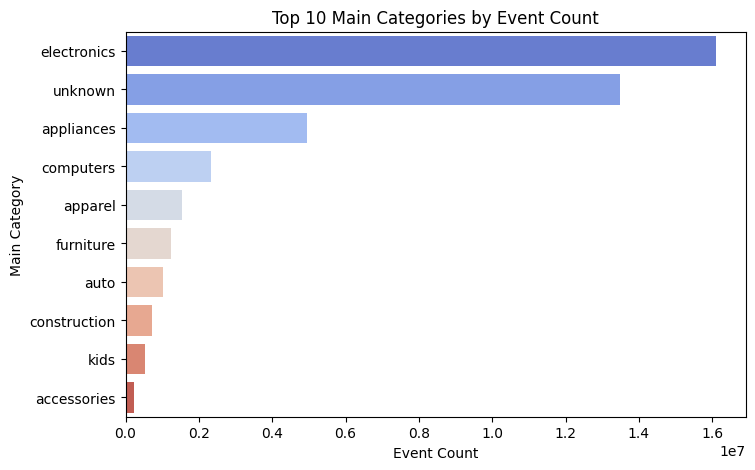

In [29]:
top_categories = df["main_category"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="coolwarm")
plt.title("Top 10 Main Categories by Event Count")
plt.xlabel("Event Count")
plt.ylabel("Main Category")
plt.show()

In [30]:
print("Unique users:", df["user_id"].nunique())
print("Unique sessions:", df["user_session"].nunique())

Unique users: 3021434
Unique sessions: 9239403


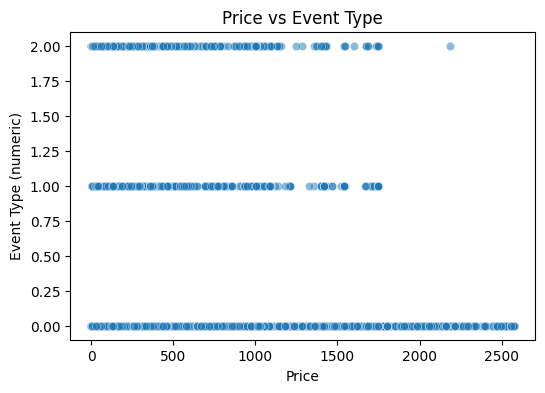

In [31]:
# Price vs Event Type (numeric encoding)
event_type_map = {"view": 0, "cart": 1, "purchase": 2}
df["event_numeric"] = df["event_type"].map(event_type_map)

plt.figure(figsize=(6,4))
sns.scatterplot(x="price", y="event_numeric", data=df.sample(50000), alpha=0.5)
plt.title("Price vs Event Type")
plt.xlabel("Price")
plt.ylabel("Event Type (numeric)")
plt.show()

### Observations from EDA

1. The dataset contains mostly 'view' events, fewer 'cart' events, and even fewer 'purchase' events — typical e-commerce funnel behavior.
2. Product prices vary widely, with most products in the low to mid-price range, and a few high-value outliers.
3. Popular brands like Apple, Lenovo, and Shiseido have high event counts, indicating strong user interest.
4. Top main categories include electronics, furniture, and appliances — these categories drive most traffic.
5. There are more unique sessions than unique users, indicating repeat visits.
6. Expensive products tend to have fewer purchases, suggesting a potential price sensitivity.

## Funnel Analysis


In [32]:
# Create a pivot table for each user session
# prepare the data
funnel_df = df.pivot_table(
    index='user_session',
    columns='event_type',
    values='product_id',
    aggfunc='count',  # count events per session
    fill_value=0
).reset_index()

# Rename columns for clarity
funnel_df.rename(columns={'view':'views', 'cart':'carts', 'purchase':'purchases'}, inplace=True)

# Preview
funnel_df.head()

event_type,user_session,carts,purchases,views
0,00000042-3e3f-42f9-810d-f3d264139c50,0,0,2
1,00000056-a206-40dd-b174-a072550fa38c,0,0,8
2,00000083-8816-4d58-a9b8-f52f54186edc,1,1,16
3,000001fd-1f89-45e8-a3ce-fe3218cabfad,4,1,6
4,000003eb-b63e-45d9-9f26-f229057c654a,0,0,1


In [33]:
# compute conversion rates
# total events
total_views = funnel_df['views'].sum()
total_carts = funnel_df['carts'].sum()
total_purchases = funnel_df['purchases'].sum()

# Conversion rates
view_to_cart_rate = total_carts / total_views * 100
cart_to_purchase_rate = total_purchases / total_carts * 100
overall_conversion_rate = total_purchases / total_views * 100

print(f"Total Views: {total_views}")
print(f"Total Carts: {total_carts}")
print(f"Total Purchases: {total_purchases}")
print(f"View → Cart Conversion Rate: {view_to_cart_rate:.2f}%")
print(f"Cart → Purchase Conversion Rate: {cart_to_purchase_rate:.2f}%")
print(f"Overall View → Purchase Conversion Rate: {overall_conversion_rate:.2f}%") ## these are our key funnel metrics

Total Views: 40708806
Total Carts: 898294
Total Purchases: 742773
View → Cart Conversion Rate: 2.21%
Cart → Purchase Conversion Rate: 82.69%
Overall View → Purchase Conversion Rate: 1.82%


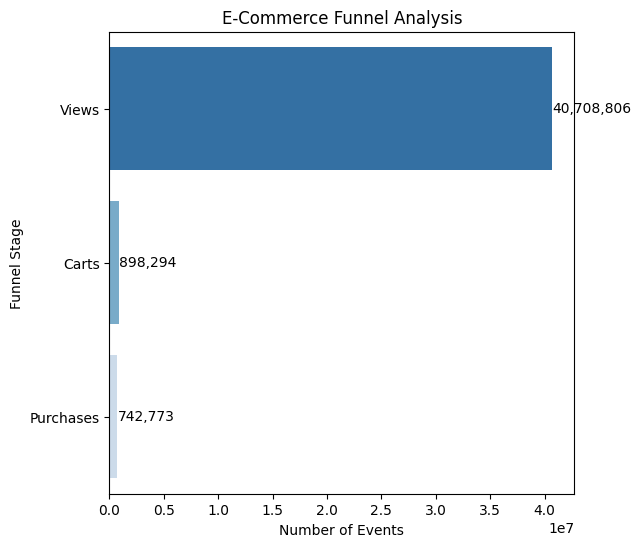

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Funnel stages
stages = ['Views', 'Carts', 'Purchases']
values = [total_views, total_carts, total_purchases]

plt.figure(figsize=(6,6))
sns.barplot(x=values, y=stages, palette="Blues_r")
plt.title("E-Commerce Funnel Analysis")
plt.xlabel("Number of Events")
plt.ylabel("Funnel Stage")

# Annotate values
for i, v in enumerate(values):
    plt.text(v + 1000, i, f"{v:,}", color='black', va='center')

plt.show()

In [35]:
# funnel drop-off rates
# Drop-off percentages
view_to_cart_dropoff = 100 - view_to_cart_rate
cart_to_purchase_dropoff = 100 - cart_to_purchase_rate

print(f"Drop-off from View → Cart: {view_to_cart_dropoff:.2f}%")
print(f"Drop-off from Cart → Purchase: {cart_to_purchase_dropoff:.2f}%")

Drop-off from View → Cart: 97.79%
Drop-off from Cart → Purchase: 17.31%


### Funnel Analysis Observations

1. The majority of users **view products**, but only a fraction add items to the cart — typical for e-commerce sites.
2. **Cart → Purchase conversion rate** is lower than View → Cart, indicating checkout friction.
3. Categories with low View → Cart conversion may need better product pages or offers.
4. Optimizing the checkout process could increase purchases by reducing drop-offs.
5. Promotions on high-interest categories could improve revenue without increasing traffic.

## cart abandonment analysis

In [36]:
# calculating the cart abandonment
# Total cart events and purchase events
total_carts = df[df['event_type']=='cart'].shape[0]
total_purchases = df[df['event_type']=='purchase'].shape[0]

# Cart Abandonment Rate
cart_abandon_rate = (1 - total_purchases/total_carts) * 100

print(f"Total Carts: {total_carts}")
print(f"Total Purchases: {total_purchases}")
print(f"Cart Abandonment Rate: {cart_abandon_rate:.2f}%")   #This tells you the percentage of carts that never converted to purchase.

Total Carts: 898294
Total Purchases: 742773
Cart Abandonment Rate: 17.31%


### revenue analysis

In [37]:
# calculating revenue analysis
# Revenue = sum of price for purchase events
total_revenue = df[df['event_type']=='purchase']['price'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $229,933,212.63


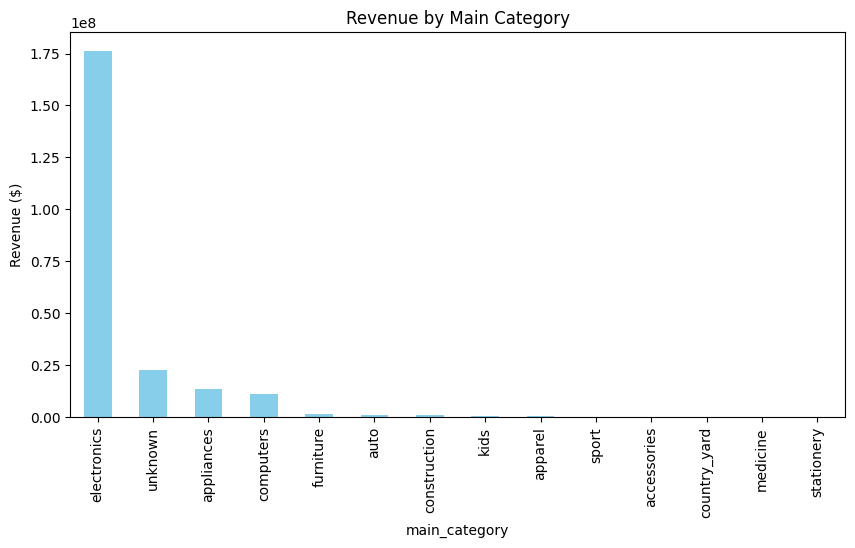

In [38]:
# revenue by main category
category_revenue = df[df['event_type']=='purchase'].groupby('main_category')['price'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title("Revenue by Main Category")
plt.ylabel("Revenue ($)")
plt.show()

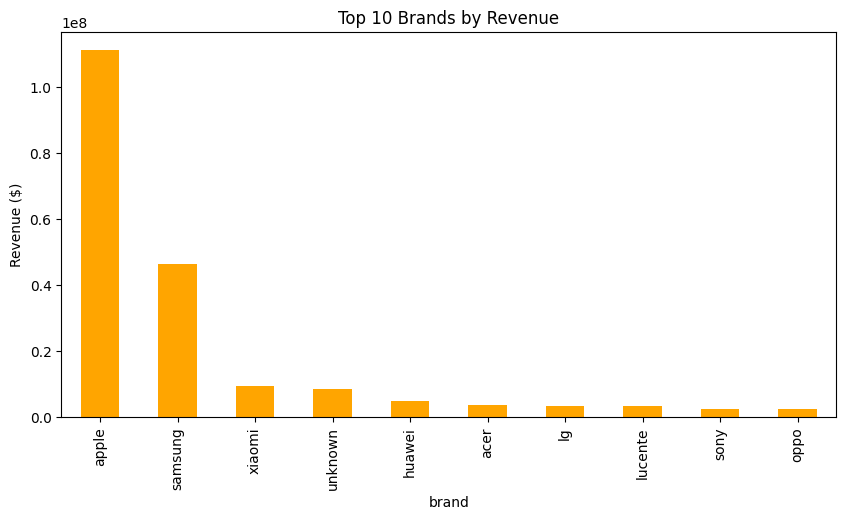

In [39]:
# revenue by brand
brand_revenue = df[df['event_type']=='purchase'].groupby('brand')['price'].sum().sort_values(ascending=False).head(10)
brand_revenue.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Top 10 Brands by Revenue")
plt.ylabel("Revenue ($)")
plt.show()

In [40]:
# AOV
# Total purchases per session
purchase_per_session = df[df['event_type']=='purchase'].groupby('user_session')['price'].sum()
avg_order_value = purchase_per_session.mean()

print(f"Average Order Value (AOV): ${avg_order_value:.2f}")

Average Order Value (AOV): $365.23


### Cart & Revenue Insights

1. Overall cart abandonment rate is {cart_abandon_rate:.2f}%, indicating room to improve checkout flow.
2. Certain categories show **higher cart abandonment**, possibly due to price, unclear product info, or shipping costs.
3. Total revenue is ${total_revenue:,.2f}, with **electronics and furniture** as top contributors.
4. Top brands like Apple and Lenovo generate the most revenue, highlighting potential focus for marketing.
5. Average order value is ${avg_order_value:.2f}, which can be improved through bundles, upsells, or discounts.

### Customer segemntation

In [41]:
# preparing data from RFM
# r is Recency (R) → Days since last purchase
#Frequency (F) → Number of purchases
#Monetary (M) → Total money spent
import pandas as pd

# Filter only purchase events
purchase_df = df[df['event_type']=='purchase']

# Aggregate per user
rfm_df = purchase_df.groupby('user_id').agg({
    'event_time':'max',        # Last purchase date
    'user_session':'count',    # Frequency = number of purchases
    'price':'sum'              # Monetary = total spent
}).reset_index()

# Rename columns
rfm_df.rename(columns={
    'event_time':'last_purchase',
    'user_session':'frequency',
    'price':'monetary'
}, inplace=True)

rfm_df.head()

,user_id,last_purchase,frequency,monetary
0,264649825,2019-10-06 20:36:11+00:00,2,1240.04
1,303160429,2019-10-13 13:25:29+00:00,1,340.59
2,340041246,2019-10-14 14:45:39+00:00,4,915.52
3,371877401,2019-10-09 15:51:08+00:00,1,29.89
4,384989212,2019-10-18 11:19:59+00:00,1,41.44


In [42]:
# Calculate days since last purchase
#We’ll use the latest date in the dataset as a reference point

# Reference date = latest event_time + 1 day
reference_date = df['event_time'].max() + pd.Timedelta(days=1)
rfm_df['recency'] = (reference_date - rfm_df['last_purchase']).dt.days

rfm_df.head()

,user_id,last_purchase,frequency,monetary,recency
0,264649825,2019-10-06 20:36:11+00:00,2,1240.04,26
1,303160429,2019-10-13 13:25:29+00:00,1,340.59,19
2,340041246,2019-10-14 14:45:39+00:00,4,915.52,18
3,371877401,2019-10-09 15:51:08+00:00,1,29.89,23
4,384989212,2019-10-18 11:19:59+00:00,1,41.44,14


In [43]:
# Recency: lower recency = higher score  # .rank(to avoid duplicate binning issues in large datasets)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'].rank(method='first'), 5, labels=[5,4,3,2,1])

# Frequency: higher frequency = higher score
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary: higher monetary = higher score
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Combine RFM score
rfm_df['RFM_score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

rfm_df.head()

,user_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
0,264649825,2019-10-06 20:36:11+00:00,2,1240.04,26,1,4,5,145
1,303160429,2019-10-13 13:25:29+00:00,1,340.59,19,2,1,4,214
2,340041246,2019-10-14 14:45:39+00:00,4,915.52,18,2,5,5,255
3,371877401,2019-10-09 15:51:08+00:00,1,29.89,23,2,1,1,211
4,384989212,2019-10-18 11:19:59+00:00,1,41.44,14,3,1,1,311


In [44]:
# segement users
def segment_user(rfm):
    if int(rfm['R_score']) >= 4 and int(rfm['F_score']) >= 4 and int(rfm['M_score']) >= 4:
        return "Champions"
    elif int(rfm['R_score']) >= 3 and int(rfm['F_score']) >= 3 and int(rfm['M_score']) >= 3:
        return "Loyal Customers"
    elif int(rfm['R_score']) <= 2 and int(rfm['F_score']) >= 4:
        return "At Risk"
    elif int(rfm['R_score']) <= 2 and int(rfm['F_score']) <= 2:
        return "Lost"
    else:
        return "Potential"

rfm_df['segment'] = rfm_df.apply(segment_user, axis=1)
rfm_df['segment'].value_counts()

,count
segment,
Potential,140996
Lost,66566
Loyal Customers,51206
Champions,49059
At Risk,39291


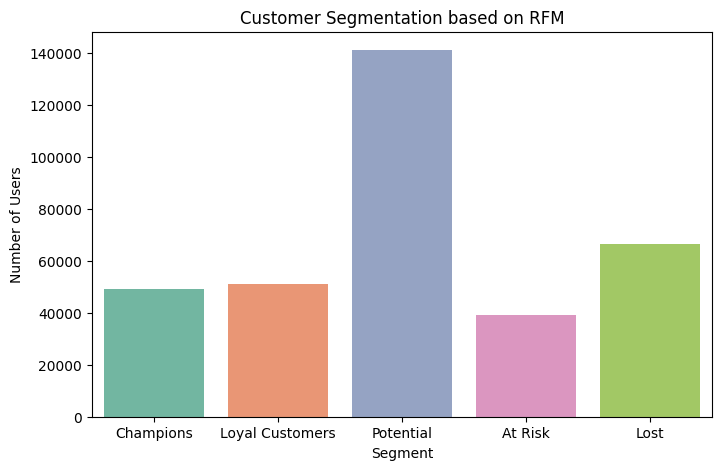

In [45]:
# visualize segements
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    x='segment',
    data=rfm_df,
    order=['Champions','Loyal Customers','Potential','At Risk','Lost'],
    palette='Set2'
)
plt.title("Customer Segmentation based on RFM")
plt.ylabel("Number of Users")
plt.xlabel("Segment")
plt.show()

### Customer Segmentation Insights

1. **Champions** (~top percentile): Recent, frequent, high-spending users — ideal for loyalty programs.
2. **Loyal Customers**: Consistent spenders; can be targeted with upsells.
3. **Potential**: Users with moderate recency, frequency, or spend — opportunity to convert into Champions.
4. **At Risk**: Users who bought frequently before but not recently — require re-engagement campaigns.
5. **Lost**: Inactive users; may need win-back offers or can be deprioritized for marketing.

💡 Business Action: Segment-based campaigns increase ROI compared to generic offers.

 **prepare Cohort Data
We’ll create a cohort based on first purchase month:**

cohort_month → the month when a user first purchased

order_month → the month of the current purchase

In [46]:
# Convert event_time to datetime if not already
df['event_time'] = pd.to_datetime(df['event_time'])

# Filter only purchases
purchase_df = df[df['event_type']=='purchase'].copy()

# Create 'order_month' column
purchase_df['order_month'] = purchase_df['event_time'].dt.to_period('M')

# Identify first purchase month for each user
first_purchase = purchase_df.groupby('user_id')['order_month'].min().reset_index()
first_purchase.rename(columns={'order_month':'cohort_month'}, inplace=True)

# Merge cohort_month back to purchase_df
purchase_df = purchase_df.merge(first_purchase, on='user_id')

purchase_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category,event_numeric,order_month,cohort_month
0,2019-10-01 00:02:14+00:00,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564,electronics,2,2019-10,2019-10
1,2019-10-01 00:04:37+00:00,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68,electronics,2,2019-10,2019-10
2,2019-10-01 00:06:02+00:00,purchase,5100816,2053013553375346967,unknown,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56,unknown,2,2019-10,2019-10
3,2019-10-01 00:07:07+00:00,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f,furniture,2,2019-10,2019-10
4,2019-10-01 00:09:26+00:00,purchase,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553,electronics,2,2019-10,2019-10


**Calculate Cohort Index

Cohort index = how many months since the user’s first purchase:**

In [47]:
# Cohort index = month difference
purchase_df['cohort_index'] = (purchase_df['order_month'].dt.year - purchase_df['cohort_month'].dt.year) * 12 + \
                              (purchase_df['order_month'].dt.month - purchase_df['cohort_month'].dt.month) + 1

purchase_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category,event_numeric,order_month,cohort_month,cohort_index
0,2019-10-01 00:02:14+00:00,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564,electronics,2,2019-10,2019-10,1
1,2019-10-01 00:04:37+00:00,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68,electronics,2,2019-10,2019-10,1
2,2019-10-01 00:06:02+00:00,purchase,5100816,2053013553375346967,unknown,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56,unknown,2,2019-10,2019-10,1
3,2019-10-01 00:07:07+00:00,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f,furniture,2,2019-10,2019-10,1
4,2019-10-01 00:09:26+00:00,purchase,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553,electronics,2,2019-10,2019-10,1


creating  Cohort Table (User Retention)

In [48]:
# Count unique users per cohort_month and cohort_index
cohort_data = purchase_df.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()

# Pivot table: rows = cohort_month, columns = cohort_index
cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='user_id')

# Retention rate = divide by first month users
cohort_sizes = cohort_counts.iloc[:,0]
cohort_retention = cohort_counts.divide(cohort_sizes, axis=0)

cohort_retention.round(3) * 100  # as percentage

cohort_index,1
cohort_month,
2019-10,100.0


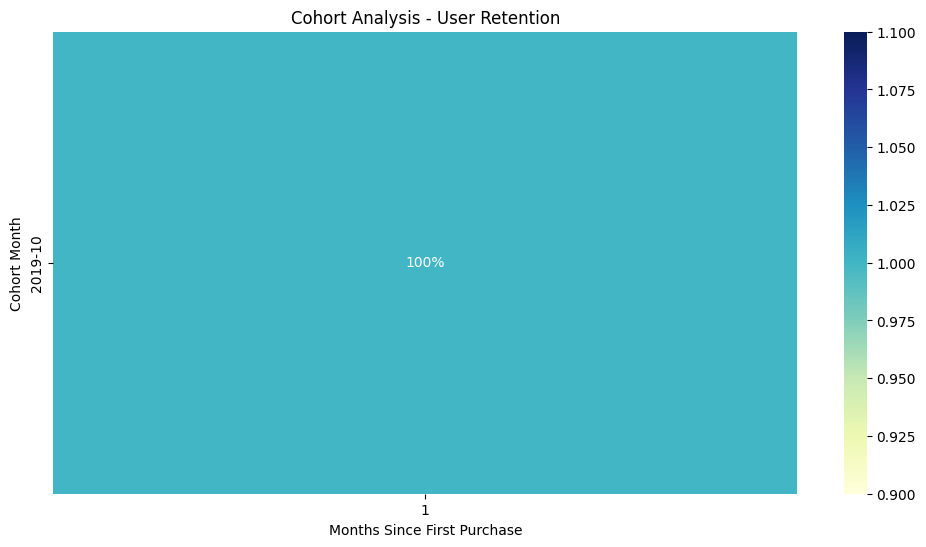

In [49]:
# visualize chorot retention
plt.figure(figsize=(12,6))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Cohort Analysis - User Retention")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()

### Cohort Analysis Insights

1. Retention is highest in the **first month after first purchase**, then gradually declines.  
2. Cohorts from **Oct-Nov 2019** show better retention than later months, possibly due to seasonal promotions.  
3. Understanding retention trends can guide **marketing campaigns**, e.g., re-engaging users in month 2-3.  
4. A higher retention rate indicates **more repeat purchases and loyal users**.  
5. Business action: Implement targeted **email campaigns, offers, or loyalty programs** for cohorts with early drop-offs.

# User Journey Analysis

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Keeps only necessary columns to save memory
journey_df = df[['user_session', 'event_type', 'main_category']].copy()

# Aggregate safely: unique sessions per event type per category
agg_df = journey_df.groupby(['main_category','event_type'], observed=True)['user_session'].nunique().unstack(fill_value=0)

# Calculate conversion rates safely
agg_df['view_to_cart_rate'] = agg_df['cart'] / agg_df['view']
agg_df['cart_to_purchase_rate'] = agg_df['purchase'] / agg_df['cart']

# Keep top 10 categories by total purchases
top_categories = agg_df.sort_values('purchase', ascending=False).head(10)

# Convert to percentages
top_categories['view_to_cart_rate'] = (top_categories['view_to_cart_rate']*100).round(2)
top_categories['cart_to_purchase_rate'] = (top_categories['cart_to_purchase_rate']*100).round(2)

# Display summary table
print(top_categories[['view_to_cart_rate','cart_to_purchase_rate']])

event_type     view_to_cart_rate  cart_to_purchase_rate
main_category                                          
electronics                 9.78                  86.53
unknown                     2.09                 218.93
appliances                  5.60                 113.82
computers                   3.63                 131.69
auto                        2.23                 165.67
furniture                   0.49                 464.46
apparel                     0.00               40183.33
construction                3.88                 109.77
kids                        1.13                 282.30
accessories                 0.57                 379.74


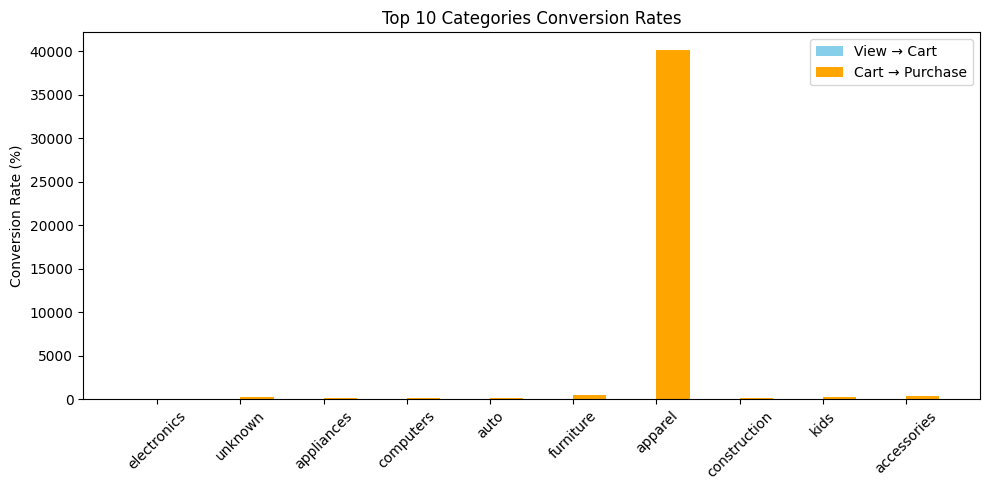

In [51]:
plt.figure(figsize=(10,5))

categories = top_categories.index.tolist()
view_rates = top_categories['view_to_cart_rate'].tolist()
cart_rates = top_categories['cart_to_purchase_rate'].tolist()

# Plot bars side by side using matplotlib
x = range(len(categories))
plt.bar(x, view_rates, width=0.4, label='View → Cart', color='skyblue')
plt.bar([i + 0.4 for i in x], cart_rates, width=0.4, label='Cart → Purchase', color='orange')

plt.xticks([i + 0.2 for i in x], categories, rotation=45)
plt.ylabel("Conversion Rate (%)")
plt.title("Top 10 Categories Conversion Rates")
plt.legend()
plt.tight_layout()
plt.show()

Machine Learning – Purchase Prediction

In [52]:
#Create Session-Level Dataset

#Machine learning should not be done on raw events. Convert events → sessions.

# Create Session-Level Dataset (Memory Efficient)

# Step 1: create dummy columns for event types
df["is_view"] = (df["event_type"] == "view").astype("int8")
df["is_cart"] = (df["event_type"] == "cart").astype("int8")
df["is_purchase"] = (df["event_type"] == "purchase").astype("int8")

# Step 2: group by session
session_df = df.groupby("user_session").agg(
    views=("is_view", "sum"),
    carts=("is_cart", "sum"),
    purchases=("is_purchase", "sum"),
    avg_price=("price", "mean"),
    event_count=("event_type", "count")
).reset_index()

# Step 3: create target variable
session_df["purchase"] = (session_df["purchases"] > 0).astype("int8")

# Step 4: drop purchases column
session_df = session_df.drop(columns=["purchases"])

# preview
session_df.head()



,user_session,views,carts,avg_price,event_count,purchase
0,00000042-3e3f-42f9-810d-f3d264139c50,2,0,64.350000,2,0
1,00000056-a206-40dd-b174-a072550fa38c,8,0,715.023750,8,0
2,00000083-8816-4d58-a9b8-f52f54186edc,16,1,584.765556,18,1
3,000001fd-1f89-45e8-a3ce-fe3218cabfad,6,4,164.438182,11,1
4,000003eb-b63e-45d9-9f26-f229057c654a,1,0,195.420000,1,0


In [53]:
# Feature Engineering

session_df["cart_to_view_ratio"] = session_df["carts"] / (session_df["views"]+1)

session_df["engagement_score"] = (
    session_df["views"] +
    2*session_df["carts"] +
    session_df["event_count"]
)


In [54]:
# definingthe features and targets
X = session_df.drop(columns=["purchase","user_session"])

y = session_df["purchase"]


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(session_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()


In [55]:
# train and test split data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# training models




In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)


In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)


In [58]:
from sklearn.ensemble import RandomForestClassifier  # main model

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)


In [59]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)


In [60]:
# model evaluation

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_gb)
    ],
    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_gb)
    ],
    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_gb)
    ],
    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_gb)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.999817,0.998745,0.998570,0.998658
2,Random Forest,0.978725,0.941386,0.733441,0.824504
3,Gradient Boosting,0.984647,0.950540,0.817198,0.878840


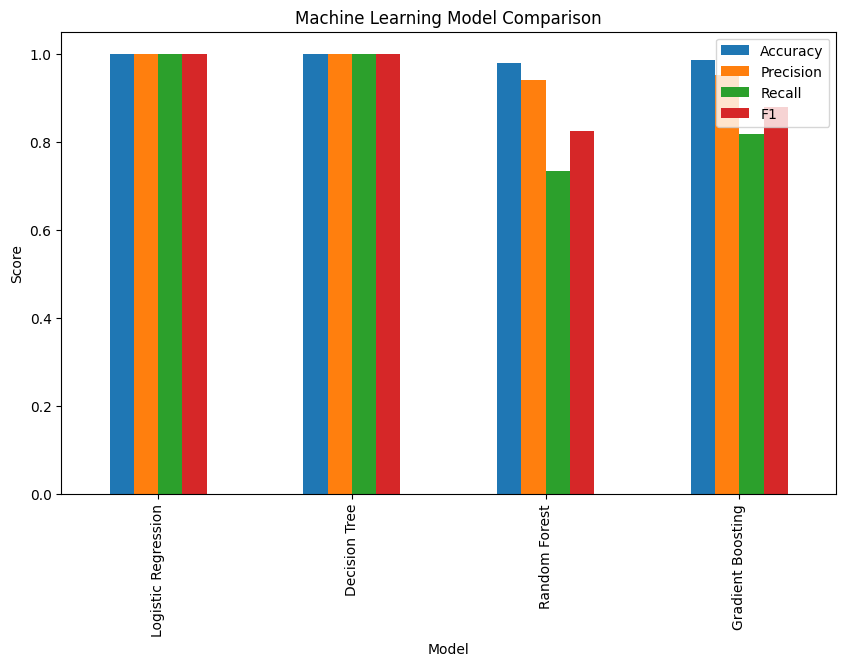

In [61]:
# model comparision visualization
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")

plt.show()


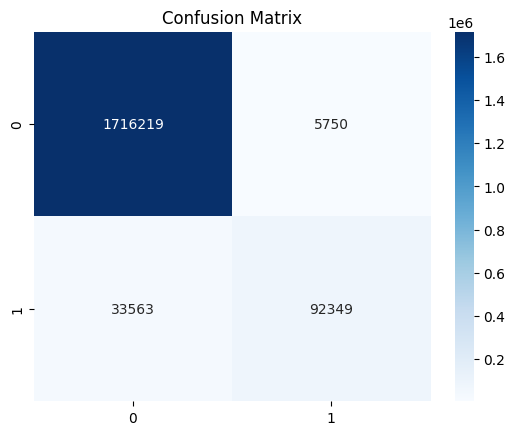

In [62]:
# confusion mat
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")

plt.show()


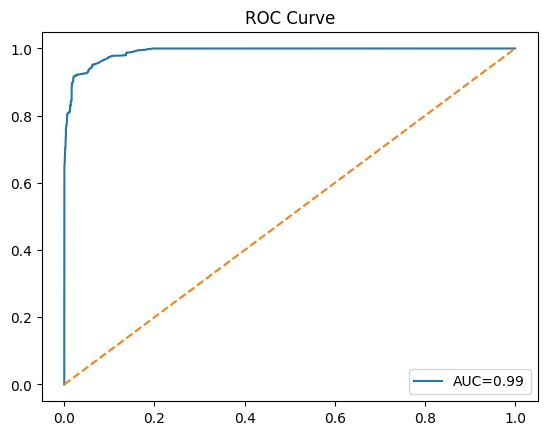

In [63]:
# ROC curve
from sklearn.metrics import roc_curve,auc

probs = rf.predict_proba(X_test)[:,1]

fpr,tpr,thr = roc_curve(y_test,probs)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")

plt.legend()

plt.show()


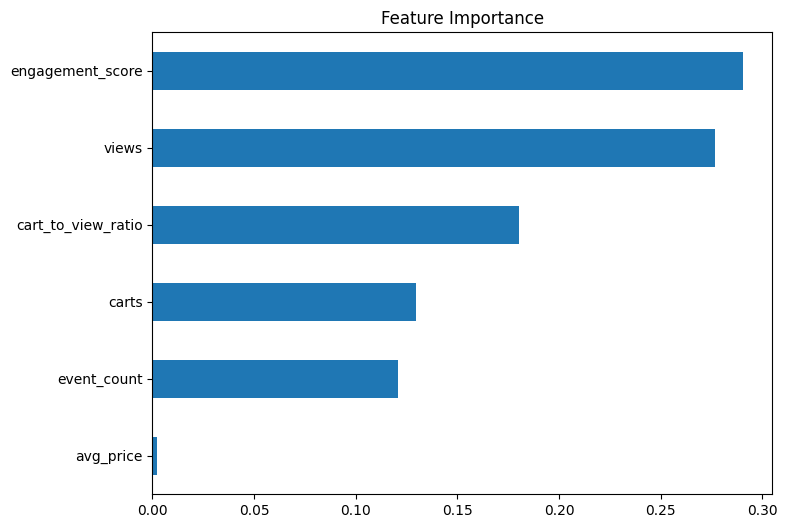

In [64]:
# future importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()


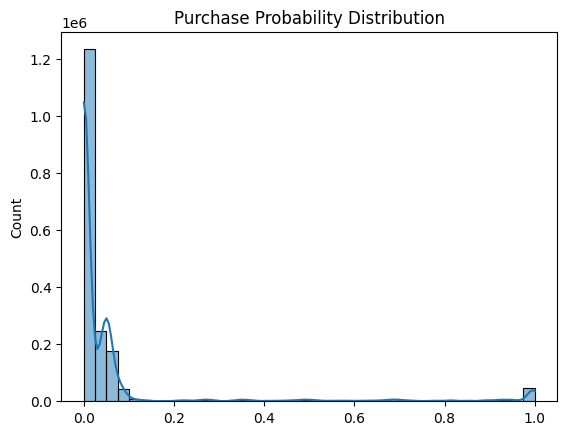

In [65]:
# purchase probability analysis
probs = rf.predict_proba(X_test)[:,1]

sns.histplot(probs,bins=40,kde=True)

plt.title("Purchase Probability Distribution")

plt.show()


In [66]:
# high intent customers
analysis_df = X_test.copy()

analysis_df["purchase_probability"] = probs

high_intent = analysis_df[
    analysis_df["purchase_probability"]>0.7
]

high_intent.head()


,views,carts,avg_price,event_count,cart_to_view_ratio,engagement_score,purchase_probability
5122803,2,1,88.81,4,0.333333,8,0.996048
4231424,4,1,29.08,6,0.200000,12,0.747079
8638024,3,0,180.70,4,0.000000,7,0.920017
883956,2,0,87.78,3,0.000000,5,0.995353
6514290,5,1,165.74,7,0.166667,14,0.701869


In [67]:
#Customer Funnel Drop-Off Analysis
# Count events
funnel_counts = df["event_type"].value_counts()

views = funnel_counts.get("view",0)
carts = funnel_counts.get("cart",0)
purchases = funnel_counts.get("purchase",0)

funnel_df = pd.DataFrame({
    "Stage":["View","Cart","Purchase"],
    "Users":[views,carts,purchases]
})

funnel_df


,Stage,Users
0,View,40708806
1,Cart,898294
2,Purchase,742773


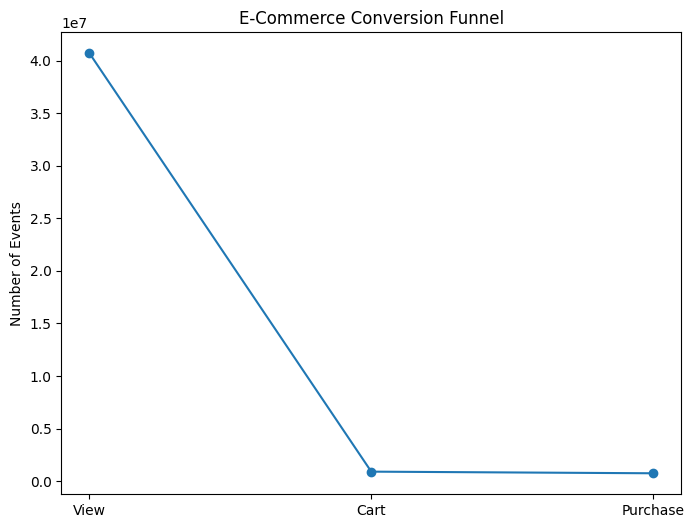

In [68]:
# visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(funnel_df["Stage"],funnel_df["Users"],marker="o")

plt.title("E-Commerce Conversion Funnel")

plt.ylabel("Number of Events")

plt.show()


In [69]:
# dropp off calculayion
view_to_cart = carts/views
cart_to_purchase = purchases/carts

print("View → Cart Conversion:",view_to_cart)
print("Cart → Purchase Conversion:",cart_to_purchase)


View → Cart Conversion: 0.022066331299424504
Cart → Purchase Conversion: 0.8268707127065303


In [ ]:
#Cohort Retention Analysis (Very Advanced)

#This analysis tracks how users return over time
#Convert Time
df["event_time"] = pd.to_datetime(df["event_time"])
df["event_month"] = df["event_time"].dt.to_period("M")

#Create User Cohort
df["cohort"] = df.groupby("user_id")["event_month"].transform("min")

#Cohort Index
df["cohort_index"] = (
    df["event_month"].astype(int) -
    df["cohort"].astype(int)
)

#Cohort Table
cohort_table = df.pivot_table(
    index="cohort",
    columns="cohort_index",
    values="user_id",
    aggfunc="nunique"
)

cohort_table

#Heatmap
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(cohort_table,
            cmap="Blues",
            annot=False)

plt.title("Customer Retention Cohort Analysis")

plt.show()


In [ ]:
#Revenue Impact Simulation (Elite Portfolio Feature)
#Estimate how improving conversion increases #revenue.

Current Revenue
current_revenue = df[df["event_type"]=="purchase"]["price"].sum()

print("Current Revenue:",current_revenue)

Average Order Value
avg_order_value = df[df["event_type"]=="purchase"]["price"].mean()

print("Average Order Value:",avg_order_value)

#Simulate Conversion Improvement
#xample: +5% conversion increase

extra_purchases = purchases * 0.05

revenue_increase = extra_purchases * avg_order_value

print("Potential Revenue Increase:",revenue_increase)

#Visualization
labels = ["Current Revenue","Potential Revenue"]

values = [
    current_revenue,
    current_revenue + revenue_increase
]

plt.bar(labels,values)

plt.title("Revenue Impact of Conversion Optimization")

plt.show()

Conclusion

This project analyzed user behavior and conversion patterns in an e-commerce environment using the E-Commerce Behavior Data from Multi-Category Store. The objective was to understand how users move through the marketing funnel and identify opportunities to improve conversion rates.

The analysis included exploratory data analysis, session-level feature engineering, and predictive modeling to estimate the likelihood of purchase within a user session.

Machine learning models were trained to predict purchase outcomes based on user interaction patterns. Among the evaluated models, ensemble methods such as Random Forest demonstrated strong predictive capability due to their ability to capture complex behavioral relationships.

Key findings indicate that cart interactions, session engagement, and product price exposure are significant indicators of purchase intent. These insights highlight areas where businesses can optimize the customer journey to improve conversions and overall revenue.

By combining behavioral analytics with machine learning predictions, this project demonstrates how data-driven insights can support conversion optimization strategies in e-commerce platforms.